# TP1 - Análisis Predictivo Avanzado
## Modelado: IBM HR Attrition

Este notebook retoma el EDA ya realizado (`EDA_Final.ipynb`) sobre el dataset **IBM HR Analytics Employee Attrition & Performance**, y se centra en la etapa de **modelado**, aplicando las técnicas avanzadas vistas en la materia:

- **Feature Engineering**: variables derivadas/ratios a partir de las columnas crudas.
- **Encoding de categóricas**: One-Hot, Ordinal, Frequency y Target Encoding.
- **Manejo de datasets desbalanceados**: `class_weight` / `scale_pos_weight` vs. SMOTE.
- **Pipelines + Optimización Bayesiana**: tuning de hiperparámetros con Optuna.
- **Métricas avanzadas** : PR-AUC, ROC-AUC, Accuracy, ganancia acumulada/lift, Cohen's Kappa y función de ganancia con costos de negocio (con nota de cuáles métricas de la clase no aplican y por qué).
- **Interpretabilidad**: SHAP values sobre el modelo final.

Problema de negocio: identificar empleados con alta probabilidad de abandonar la empresa (`Attrition`), para poder anticipar acciones de retención. Es un problema de **clasificación binaria desbalanceada** (~16% de attrition).


In [ ]:
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42


## 1. Carga de datos y preprocesamiento base

Reproducimos, de forma resumida, la limpieza ya definida y justificada en el EDA (mismas decisiones, sin repetir el análisis exploratorio): eliminación de columnas sin información, winsorización de las variables de años (p95 / cortes fijos), mapeo de variables binarias y la variable `MeanSatisfaction`.


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/JuliaSexe/Examen-1---An-lisis-Predictivo/refs/heads/main/IBM%20-%20HR-Employee-Attrition.csv')

# Columnas sin información (constantes / identificador ya usado en el EDA)
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)

# Winsorización (mismos cortes que en el EDA)
df['YearsAtCompany'] = df['YearsAtCompany'].clip(upper=df['YearsAtCompany'].quantile(0.95))
df['YearsInCurrentRole'] = df['YearsInCurrentRole'].clip(upper=df['YearsInCurrentRole'].quantile(0.95))
df['YearsSinceLastPromotion'] = df['YearsSinceLastPromotion'].clip(upper=8)
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].clip(upper=10)

# Variables binarias a 0/1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Feature de satisfacción promedio (igual que en el EDA)
cols_satisfaction = [c for c in df.columns if 'satisfaction' in c.lower()]
df['MeanSatisfaction'] = df[cols_satisfaction].sum(axis=1) / len(cols_satisfaction)

print(df.shape)
df.head()


(1470, 32)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MeanSatisfaction
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,2.333333
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,3.000000
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,3.000000
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,3.333333
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,2.333333


In [ ]:
# Variables categóricas nominales (sin orden natural) vs. el resto, ya numéricas u ordinales
vars_cat_nominales = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
target = 'Attrition'

print('Distribución del target:')
print(df[target].value_counts(normalize=True))


Distribución del target:
Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


## 1.1 Feature Engineering adicional

Armamos algunas razones/ratios con sentido de negocio:

- `IncomePerYearWorked`: ingreso mensual relativo a la experiencia total (¿está mal pago para su experiencia?).
- `TenureRatio`: qué proporción de su vida laboral total pasó en esta empresa (¿es "nuevo" en su carrera o ya rotó mucho antes de llegar?).
- `PromotionRate`: qué tan seguido lo promocionan en relación a su antigüedad (¿estancado?).
- `JobHoppingRate`: cantidad de empresas previas relativa a los años trabajados (historial de rotación).
- `AgeAtJoining`: edad aproximada a la que entró a la empresa actual.


In [ ]:
df['IncomePerYearWorked'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['PromotionRate'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['JobHoppingRate'] = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)
df['AgeAtJoining'] = df['Age'] - df['YearsAtCompany']

nuevas_features = ['IncomePerYearWorked', 'TenureRatio', 'PromotionRate', 'JobHoppingRate', 'AgeAtJoining']
df[nuevas_features].describe()


,IncomePerYearWorked,TenureRatio,PromotionRate,JobHoppingRate,AgeAtJoining
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,587.575385,0.573721,0.227617,0.278598,30.172109
std,284.650784,0.278372,0.257625,0.294419,9.158964
min,95.285714,0.000000,0.000000,0.000000,18.000000
25%,374.232143,0.368421,0.000000,0.090909,23.000000
50%,549.220648,0.625000,0.142857,0.176471,29.000000
75%,738.303846,0.833333,0.380952,0.390700,36.000000
max,1904.000000,0.952381,0.875000,2.250000,59.000000


**Por qué el +1 en los denominadores**: varios empleados tienen *TotalWorkingYears = 0* (primer trabajo) o *YearsAtCompany = 0* (recién ingresados). Sin el *+1*, esas filas producirían división por cero (inf/NaN), lo cual rompería el entrenamiento. Correr el denominador una unidad evita esto y, de paso, amortigua ratios extremos cuando el denominador original es muy chico (ej. 1 año de experiencia).

In [ ]:
# ¿Aportan señal? Miramos su correlación con el target
df[nuevas_features + [target]].corr()[target].sort_values(ascending=False)


,Attrition
Attrition,1.000000
JobHoppingRate,0.199986
IncomePerYearWorked,0.097731
PromotionRate,0.013186
AgeAtJoining,-0.067844
TenureRatio,-0.094044


## 2. Split train/test estratificado

Separamos antes de ajustar cualquier encoder o modelo, para evitar data leakage.


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(X_train.shape, X_test.shape)


(1176, 36) (294, 36)


**Por qué stratify=y**: el target está desbalanceado (~16% de attrition sobre 1470 registros, ~237 casos positivos). Un split aleatorio simple podría dejar, por azar, una proporción de attrition distinta en train y en test, sesgando tanto la comparación entre encoders/modelos como el PR-AUC (que, a diferencia de ROC-AUC, es sensible a la proporción de positivos del set de evaluación). *stratify=y* preserva la proporción real de la clase minoritaria en ambos splits.

## 3. Encoding de variables categóricas

Comparamos, sobre un mismo modelo baseline (XGBoost sin tunear), cuatro formas de codificar las categóricas nominales: **One-Hot**, **Ordinal**, **Frequency Encoding** y **Target Encoding**.


In [ ]:
!pip install category_encoders feature_engine
from category_encoders import TargetEncoder
from feature_engine.encoding import CountFrequencyEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

def preparar_encoding(encoder, nombre):
    ct = ColumnTransformer(
        transformers=[(nombre, encoder, vars_cat_nominales)],
        remainder='passthrough',
        verbose_feature_names_out=False
    ).set_output(transform='pandas')

    X_train_enc = ct.fit_transform(X_train, y_train)
    X_test_enc = ct.transform(X_test)
    return X_train_enc, X_test_enc

encoders = {
    'One-Hot': OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
    'Ordinal': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Frequency': CountFrequencyEncoder(encoding_method='frequency', missing_values='ignore'),
    'Target': TargetEncoder(),
}

resultados_encoding = {}
datasets_encoding = {}

for nombre, encoder in encoders.items():
    X_train_enc, X_test_enc = preparar_encoding(encoder, nombre)
    modelo = XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr')
    modelo.fit(X_train_enc, y_train)
    proba = modelo.predict_proba(X_test_enc)[:, 1]
    pr_auc = average_precision_score(y_test, proba)
    resultados_encoding[nombre] = pr_auc
    datasets_encoding[nombre] = (X_train_enc, X_test_enc)
    print(f'{nombre:10s} -> PR-AUC test: {pr_auc:.3f}')

mejor_encoding = max(resultados_encoding, key=resultados_encoding.get)
print(f'\nMejor encoding: {mejor_encoding}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 12.0 MB/s eta 0:00:00
One-Hot    -> PR-AUC test: 0.426
Ordinal    -> PR-AUC test: 0.497


/usr/local/lib/python3.13/dist-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
/usr/local/lib/python3.13/dist-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
/usr/local/lib/python3.13/dist-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
/usr/local/lib/pyth

Frequency  -> PR-AUC test: 0.434
Target     -> PR-AUC test: 0.437

Mejor encoding: Ordinal


In [ ]:
X_train_enc, X_test_enc = datasets_encoding[mejor_encoding]
print(f'Usamos el encoding "{mejor_encoding}" para el resto del notebook.')
X_train_enc.head()


Usamos el encoding "Ordinal" para el resto del notebook.


,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MeanSatisfaction,IncomePerYearWorked,TenureRatio,PromotionRate,JobHoppingRate,AgeAtJoining
0,2.0,2.0,1.0,0.0,3.0,0.0,47,1225,2,4,2,47,4,4,2,15972,21086,6,0,14,3,3,3,29,2,3,3,2,1,2,2.333333,532.400000,0.100000,0.250000,0.200000,44
1,2.0,1.0,5.0,1.0,2.0,1.0,22,594,2,1,3,100,3,1,4,2523,19299,0,0,14,3,3,1,3,2,3,2,1,2,1,3.333333,630.750000,0.500000,0.666667,0.000000,20
2,2.0,2.0,2.0,1.0,3.0,1.0,46,406,3,1,1,52,3,4,3,17465,15596,3,0,12,3,4,1,23,3,3,12,9,4,9,2.666667,727.708333,0.500000,0.307692,0.125000,34
3,2.0,2.0,3.0,1.0,8.0,1.0,25,622,13,1,2,40,3,1,3,2096,26376,1,0,11,3,3,0,7,1,3,7,4,0,6,2.666667,262.000000,0.875000,0.000000,0.125000,18
4,1.0,1.0,3.0,1.0,2.0,0.0,43,1001,9,5,4,72,3,2,3,5679,19627,3,1,13,3,2,1,10,3,3,8,7,4,7,3.000000,516.272727,0.727273,0.444444,0.272727,35


**Nota metodológica**: esta comparación evalúa cada encoder sobre un único split de test. Con un dataset de 1470 filas (~237 positivos), el resultado puede tener cierta varianza frente a otra semilla de split — se prioriza simplicidad sobre exhaustividad para esta comparación exploratoria; el modelo final (sección 5 en adelante) sí se valida con cross-validation estratificado de 5 folds.

**Sobre el encoder ganador (Ordinal)**: llama la atención que gane Ordinal Encoding, ya que asigna números arbitrarios a categorías sin orden real (ej. JobRole, MaritalStatus). Sin embargo, XGBoost al ser un modelo de árboles puede encontrar splits binarios útiles sobre esos números aunque no representen un orden verdadero — no es la razón "de diseño" del encoding, pero explica por qué no perjudica la performance acá.

## 4. Manejo del desbalance de clases
El target está desbalanceado (~16% de attrition), por lo que comparamos tres enfoques vistos en clase sobre tres modelos representativos (Regresión Logística como baseline, Random Forest y XGBoost):

1. **Sin balancear** (baseline).
2. **`class_weight="balanced"`** (sklearn) / **`scale_pos_weight`** (XGBoost).
3. **SMOTE** (oversampling sintético, `imblearn`).

Usamos **PR-AUC** (`average_precision_score`) como métrica de comparación en vez de accuracy o ROC-AUC, porque es más informativa en datasets desbalanceados.


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Escalamos (necesario para Regresión Logística; no afecta a los modelos basados en árboles)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_test_sc = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight calculado: {scale_pos_weight:.2f}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)
print('Distribución tras SMOTE:', y_train_smote.value_counts().to_dict())


scale_pos_weight calculado: 5.19
Distribución tras SMOTE: {0: 986, 1: 986}


In [ ]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te):
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pr_auc = average_precision_score(y_test, proba)
    print(f'{nombre:45s} -> PR-AUC test: {pr_auc:.3f}')
    return pr_auc

resultados_balance = {}

# --- Sin balancear ---
resultados_balance['LogReg (baseline)'] = evaluar(
    'LogReg (baseline)', LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    X_train_sc, y_train, X_test_sc)
resultados_balance['RandomForest (baseline)'] = evaluar(
    'RandomForest (baseline)', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_enc, y_train, X_test_enc)
resultados_balance['XGBoost (baseline)'] = evaluar(
    'XGBoost (baseline)', XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr'),
    X_train_enc, y_train, X_test_enc)

# --- class_weight / scale_pos_weight ---
resultados_balance['LogReg class_weight=balanced'] = evaluar(
    'LogReg class_weight=balanced', LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_sc, y_train, X_test_sc)
resultados_balance['RandomForest class_weight=balanced'] = evaluar(
    'RandomForest class_weight=balanced', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    X_train_enc, y_train, X_test_enc)
resultados_balance['XGBoost scale_pos_weight'] = evaluar(
    'XGBoost scale_pos_weight', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='aucpr'),
    X_train_enc, y_train, X_test_enc)

# --- SMOTE ---
resultados_balance['LogReg + SMOTE'] = evaluar(
    'LogReg + SMOTE', LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    X_train_smote, y_train_smote, X_test_sc)
resultados_balance['RandomForest + SMOTE'] = evaluar(
    'RandomForest + SMOTE', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_smote, y_train_smote, X_test_sc)
resultados_balance['XGBoost + SMOTE'] = evaluar(
    'XGBoost + SMOTE', XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr'),
    X_train_smote, y_train_smote, X_test_sc)

mejor_combo = max(resultados_balance, key=resultados_balance.get)
print(f'\nMejor combinación modelo/balanceo: {mejor_combo} (PR-AUC={resultados_balance[mejor_combo]:.3f})')


LogReg (baseline)                             -> PR-AUC test: 0.600
RandomForest (baseline)                       -> PR-AUC test: 0.406
XGBoost (baseline)                            -> PR-AUC test: 0.497
LogReg class_weight=balanced                  -> PR-AUC test: 0.602
RandomForest class_weight=balanced            -> PR-AUC test: 0.381
XGBoost scale_pos_weight                      -> PR-AUC test: 0.471
LogReg + SMOTE                                -> PR-AUC test: 0.599
RandomForest + SMOTE                          -> PR-AUC test: 0.448
XGBoost + SMOTE                               -> PR-AUC test: 0.497

Mejor combinación modelo/balanceo: LogReg class_weight=balanced (PR-AUC=0.602)


**Nota**: en esta corrida, la Regresión Logística (con o sin balanceo) obtiene el PR-AUC más alto de la comparación. Aun así, seguimos con **XGBoost + `scale_pos_weight`** para la etapa siguiente, porque el objetivo del TP es poner en práctica las técnicas nuevas de la materia (optimización bayesiana con Optuna y SHAP con `TreeExplainer`, pensados para modelos de árboles), y porque en la práctica un modelo de boosting bien tuneado suele terminar superando a la regresión logística. Si el objetivo fuera únicamente maximizar el PR-AUC de test, la Regresión Logística sería la elección directa.

## 5. Optimización bayesiana de hiperparámetros

Tuneamos **XGBoost + `scale_pos_weight`** con **Optuna** (sampler TPE), optimizando el PR-AUC por validación cruzada estratificada.


In [ ]:
from sklearn.pipeline import Pipeline

# Reconstruimos el ColumnTransformer con el encoder que ganó en la sección 3 (Ordinal)
encoder_ganador = encoders[mejor_encoding]

ct_final = ColumnTransformer(
    transformers=[(mejor_encoding, encoder_ganador, vars_cat_nominales)],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

pipeline = Pipeline([
    ('encoding', ct_final),
    ('modelo', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='aucpr'))
])

**Por qué envolver encoding + modelo en un `Pipeline`**: a partir de acá, el encoding ya no se calcula una sola vez sobre todo `X_train` — se recalcula dentro de cada fold del cross-validation que usa Optuna (sección 5). Esto es relevante porque el Target/Ordinal Encoding usa información del target para transformar las categóricas; si el encoding se calculara una sola vez afuera del CV, cada fold de validación "vería" (indirectamente) información calculada con datos que en ese fold deberían estar fuera del entrenamiento. Con el `Pipeline`, cada fold refitea el encoder solo con su propio train, evitando esa fuga de información. Es el mismo patrón (`Pipeline` + optimización bayesiana) usado en la materia.

In [ ]:
!pip install optuna
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'modelo__n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'modelo__max_depth': trial.suggest_int('max_depth', 2, 10),
        'modelo__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'modelo__subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'modelo__colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
    pipeline.set_params(**params)
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision').mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=40)

print('Mejor PR-AUC (CV):', round(study.best_value, 3))
print('Mejores hiperparámetros:', study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.4 MB/s eta 0:00:00
Mejor PR-AUC (CV): 0.619
Mejores hiperparámetros: {'n_estimators': 181, 'max_depth': 2, 'learning_rate': 0.05616073956358163, 'subsample': 0.612194108012852, 'colsample_bytree': 0.6140474080406957}


In [ ]:
# Reentrenamos el pipeline completo con los mejores hiperparámetros encontrados
best_params = {f'modelo__{k}': v for k, v in study.best_params.items()}

pipeline.set_params(**best_params)
pipeline.fit(X_train, y_train)

proba_final = pipeline.predict_proba(X_test)[:, 1]
pr_auc_final = average_precision_score(y_test, proba_final)
print(f'PR-AUC del modelo final en test: {pr_auc_final:.3f}')
print(f'(vs. baseline sin tunear: {resultados_balance["XGBoost scale_pos_weight"]:.3f})')

PR-AUC del modelo final en test: 0.527
(vs. baseline sin tunear: 0.471)


## 6. Evaluación con métricas avanzadas

Además del PR-AUC, miramos la curva Precision-Recall y una **función de ganancia** con costos de negocio: el costo de no detectar a alguien que se va (falso negativo, se pierde por completo el costo de reemplazo) es mucho mayor que el de ofrecer una intervención de retención a alguien que en realidad se iba a quedar (falso positivo).


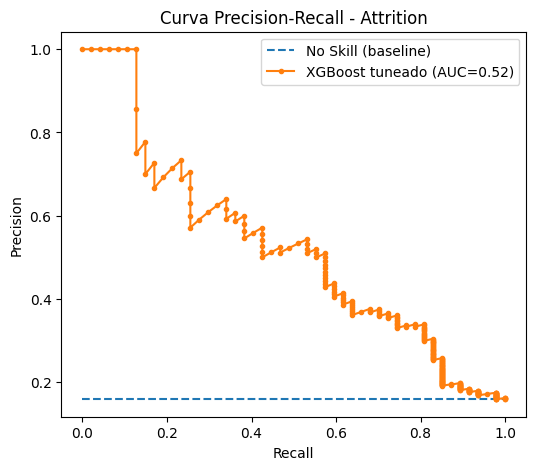

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.39      0.62      0.48        47

    accuracy                           0.78       294
   macro avg       0.65      0.72      0.67       294
weighted avg       0.83      0.78      0.80       294



In [ ]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report

precision, recall, thresholds = precision_recall_curve(y_test, proba_final)
pr_auc_curve = auc(recall, precision)

plt.figure(figsize=(6, 5))
no_skill = y_test.mean()
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (baseline)')
plt.plot(recall, precision, marker='.', label=f'XGBoost tuneado (AUC={pr_auc_curve:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Attrition')
plt.legend()
plt.show()

y_pred_05 = (proba_final >= 0.5).astype(int)
print(classification_report(y_test, y_pred_05))


Con el punto de corte por defecto (0.5), el modelo detecta al 62% de la gente que realmente se va (recall), pero de cada 10 personas que marca como "riesgo", solo 4 efectivamente se iban (precision 0.39). El PR-AUC de 0.52 está muy por encima del "No Skill" (~0.16), así que el modelo sí aporta señal real — solo que a este punto de corte prioriza no dejar pasar casos por sobre no generar falsas alarmas.

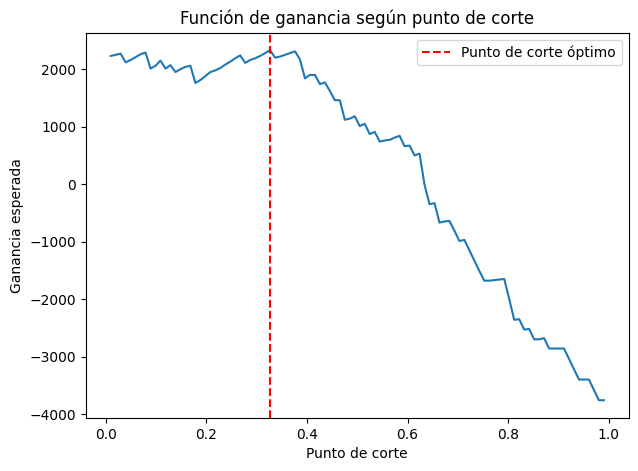

Punto de corte que maximiza la ganancia esperada: 0.33 (ganancia=2330)


In [ ]:
def metricas_por_punto_corte(y_true, y_proba, costo_tp, costo_tn, costo_fp, costo_fn, n_puntos=100):
    """
    Calcula la ganancia esperada del modelo para distintos puntos de corte,
    a partir de costos unitarios de negocio para cada tipo de acierto/error.
    """
    filas = []
    for pc in np.linspace(0.01, 0.99, n_puntos):
        y_pred = (y_proba >= pc).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        ganancia = tp * costo_tp + tn * costo_tn + fp * costo_fp + fn * costo_fn
        filas.append({'pc': pc, 'ganancia': ganancia, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})
    return pd.DataFrame(filas)

# Costos ilustrativos (ajustar con datos reales de la empresa):
# - Detectar y retener a tiempo a alguien que se iba a ir (TP): ahorro grande.
# - No hacer nada con alguien que se queda igual (TN): sin costo.
# - Ofrecer intervención a alguien que no se iba a ir (FP): costo bajo de la intervención.
# - No detectar a alguien que se va (FN): se pierde todo el costo de reemplazo.
costo_tp, costo_tn, costo_fp, costo_fn = 100, 0, -10, -80

metricas_df = metricas_por_punto_corte(y_test, proba_final, costo_tp, costo_tn, costo_fp, costo_fn)

plt.figure(figsize=(7, 5))
sns.lineplot(data=metricas_df, x='pc', y='ganancia')
plt.axvline(metricas_df.loc[metricas_df['ganancia'].idxmax(), 'pc'], color='red', linestyle='--', label='Punto de corte óptimo')
plt.xlabel('Punto de corte')
plt.ylabel('Ganancia esperada')
plt.title('Función de ganancia según punto de corte')
plt.legend()
plt.show()

punto_optimo = metricas_df.loc[metricas_df['ganancia'].idxmax()]
print(f"Punto de corte que maximiza la ganancia esperada: {punto_optimo['pc']:.2f} (ganancia={punto_optimo['ganancia']:.0f})")


El punto de corte que más plata/valor genera para el negocio es 0.33, no 0.5 — con ganancia esperada de 2330. Después de ese punto, la ganancia cae y hasta se vuelve negativa (a partir de ~0.62).

### 6.1 Comparación contra las métricas "normales" (ROC-AUC, Accuracy)

Comparamos el PR-AUC contra ROC-AUC y Accuracy para el mismo modelo, para ver en concreto por qué el PR-AUC es más exigente/informativo con este nivel de desbalance (~16%).


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

acc = accuracy_score(y_test, y_pred_05)
roc_auc_val = roc_auc_score(y_test, proba_final)

print(f'Accuracy (pc=0.5):        {acc:.3f}   <- engañosa: predecir siempre "no se va" ya da {1 - y_test.mean():.3f}')
print(f'ROC-AUC:                  {roc_auc_val:.3f}')
print(f'PR-AUC (average precision): {pr_auc_final:.3f}   <- se compara contra el baseline de {y_test.mean():.3f} (tasa real de attrition), no contra 0.5')


Accuracy (pc=0.5):        0.782   <- engañosa: predecir siempre "no se va" ya da 0.840
ROC-AUC:                  0.785
PR-AUC (average precision): 0.527   <- se compara contra el baseline de 0.160 (tasa real de attrition), no contra 0.5


**Por qué la Accuracy engaña acá**: con el punto de corte de 0.5, la Accuracy del modelo (0.782) es *menor* a la que se obtiene con un modelo trivial que predice "nadie se va" (0.840) — mirando solo Accuracy, el modelo parecería peor que no hacer nada. Esto pasa porque el modelo está sacrificando aciertos totales a cambio de detectar más casos reales de attrition, que es justamente lo que le importa al negocio (y lo que Accuracy no puede medir, porque le da el mismo peso a todos los aciertos, incluidos los triviales). El **PR-AUC (0.527)**, en cambio, sí refleja ese valor: compara contra el baseline real (16%, la tasa de attrition), no contra un 50% arbitrario, y por eso es la métrica que se usa en el resto del notebook para comparar encoders, balanceo y modelos.

### 6.2 Curva de ganancia acumulada y Lift

Además de la función de ganancia por costos, vimos las curvas de **ganancia acumulada** y **lift por decil** (librería `kds`), típicas de modelos de scoring/marketing: ordenan a los empleados de mayor a menor probabilidad de attrition y muestran cuántos "positivos reales" se capturan mirando sólo el top X% del ranking. **Sí aplican** acá: el uso de negocio (priorizar a quién contactar primero para retención) es exactamente ese escenario de ranking.


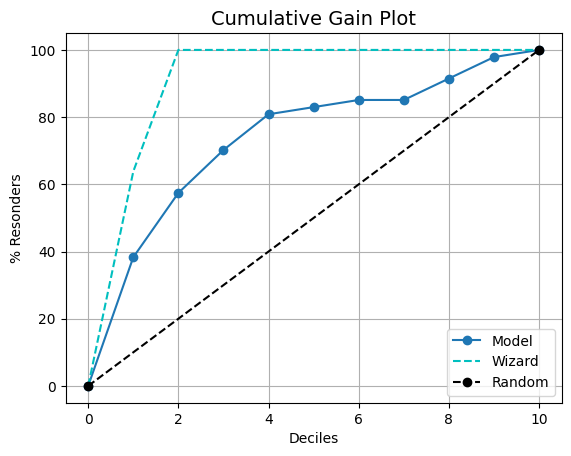

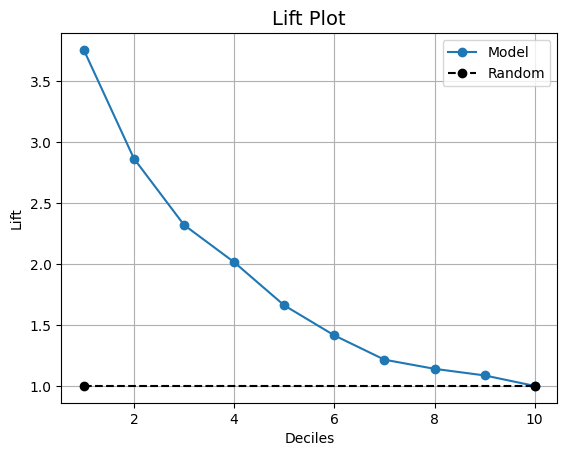

In [ ]:
!pip install kds
import kds

kds.metrics.plot_cumulative_gain(y_test.values, proba_final)
plt.show()

kds.metrics.plot_lift(y_test.values, proba_final)
plt.show()

Mirando solo el 20% de los empleados con mayor riesgo según el modelo (2 deciles), ya se captura cerca del 58% de la gente que realmente se va — muy por encima del 20% que capturaría el azar. En el decil de mayor riesgo, el lift es de 3.75x: contactar primero a ese grupo es casi 4 veces más eficiente que elegir al azar. Este gráfico es el que mejor sostiene la acción de negocio (priorizar recursos limitados de RRHH).

### 6.3 Índice Kappa

Kappa se mostró en un ejemplo **multiclase**. Acá el problema es binario, así que no tiene el mismo rol central que en ese ejemplo, pero **sí se puede calcular para 2 clases** (compara el acuerdo observado contra el que se esperaría por azar dado el desbalance de clases) y sirve como chequeo adicional a la Accuracy.

Las métricas ROC-AUC multiclase (macro/weighted) y las de **drift**, en cambio, **no aplican**: la primera porque el target es binario, no multiclase; la segunda porque son para comparar dos períodos/datasets distintos en producción (data drift, target drift), y acá tenemos un único dataset estático, sin ventana temporal de referencia.


In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred_05)
print(f'Cohen\'s Kappa (pc=0.5): {kappa:.3f}')
print('Referencia: <0 sin acuerdo, 0-0.2 leve, 0.2-0.4 aceptable, 0.4-0.6 moderado, 0.6-0.8 sustancial, >0.8 casi perfecto.')


Cohen's Kappa (pc=0.5): 0.347
Referencia: <0 sin acuerdo, 0-0.2 leve, 0.2-0.4 aceptable, 0.4-0.6 moderado, 0.6-0.8 sustancial, >0.8 casi perfecto.


**Lectura del Kappa**: 0.347 cae en el rango "aceptable" (0.2-0.4) de la escala de referencia usada arriba — hay acuerdo real entre las predicciones del modelo y la realidad, por encima de lo que se esperaría solo por azar dado el desbalance de clases, pero no es un acuerdo fuerte. Es consistente con lo que ya mostró la curva Precision-Recall (precision de 0.39 con el punto de corte de 0.5): el modelo aporta valor real, pero está lejos de ser perfecto, y esa limitación conviene comunicarla con honestidad en la presentación en vez de sobrevender el resultado.

## 7. Interpretabilidad con SHAP

Usamos **SHAP** (`TreeExplainer`, apto para modelos basados en árboles como XGBoost) para entender qué variables más influyen en la predicción de attrition, tanto a nivel global como para casos individuales.


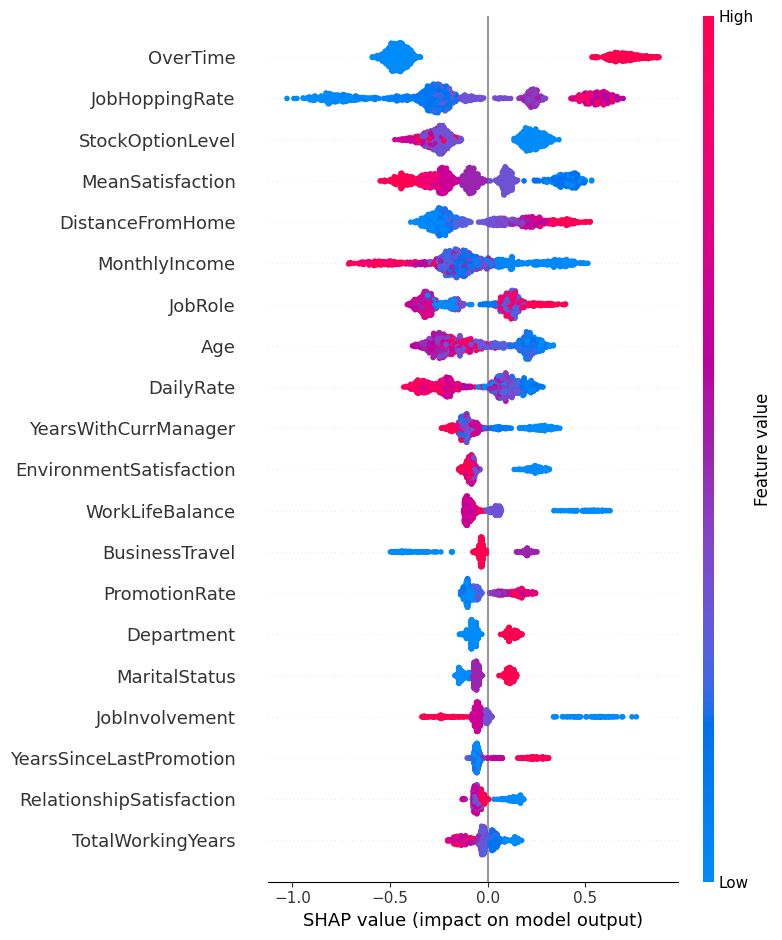

In [ ]:
import shap
# Sacamos el modelo XGBoost puro de adentro del pipeline (SHAP necesita el modelo, no el pipeline)
modelo_final = pipeline.named_steps['modelo']

# Transformamos los datos con el encoding ya aprendido (sin volver a fitear)
X_train_enc = pipeline.named_steps['encoding'].transform(X_train)
X_test_enc = pipeline.named_steps['encoding'].transform(X_test)

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_train_enc)
shap.summary_plot(shap_values, X_train_enc)

Las variables que más pesan son OverTime, JobHoppingRate, StockOptionLevel, MeanSatisfaction y DistanceFromHome. Lo interesante es que las direcciones tienen sentido de negocio: hacer horas extra (rojo = sí) empuja fuerte hacia attrition; historial de rotación alto también; no tener stock options empuja hacia attrition; baja satisfacción e ingreso bajo también empujan hacia irse.

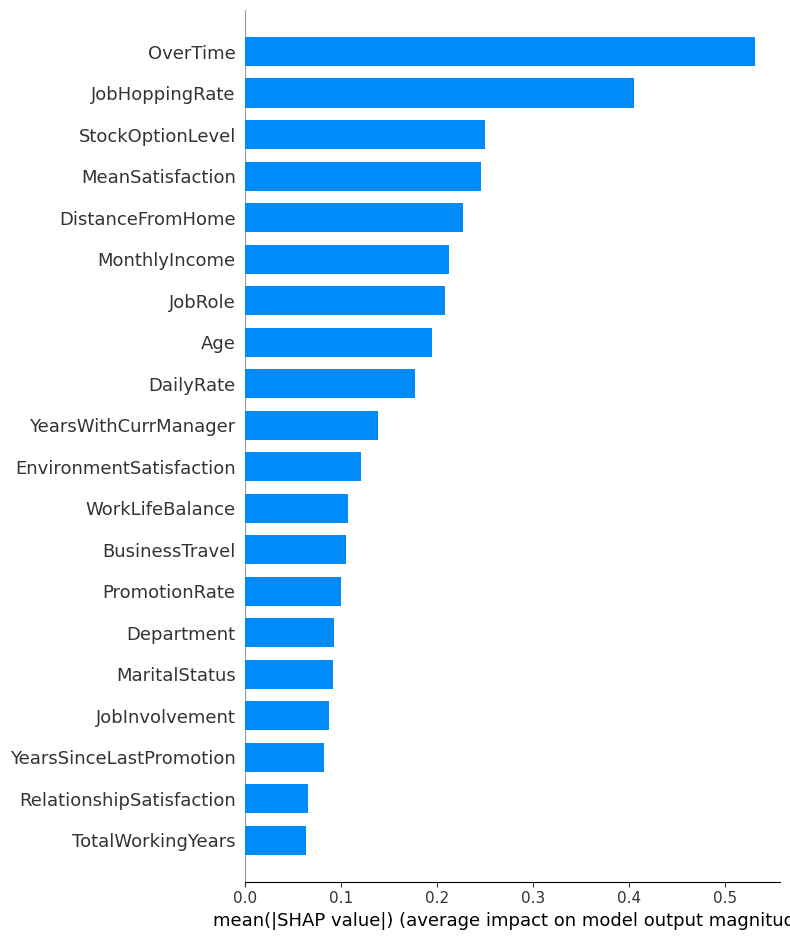

In [ ]:
shap.summary_plot(shap_values, X_train_enc, plot_type='bar')


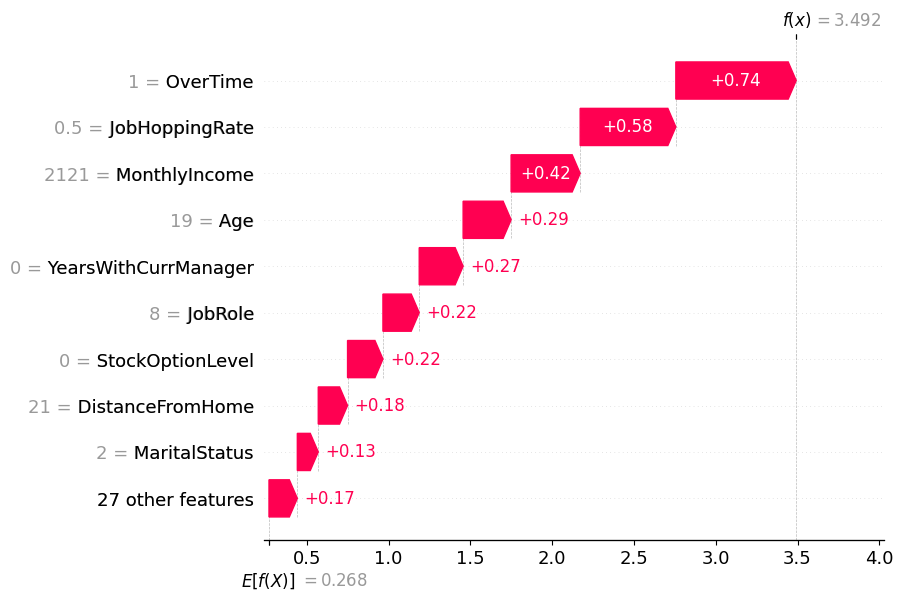

In [ ]:
# Explicación individual: el caso con mayor probabilidad de attrition predicha en test
idx_riesgo_alto = int(np.argmax(proba_final))
shap_values_test = explainer(X_test_enc)
shap.plots.waterfall(shap_values_test[idx_riesgo_alto])


**Lectura del caso individual**: el empleado con mayor riesgo predicho es alguien joven (19 años), que hace horas extra, con historial de rotación previo, sueldo relativamente bajo, sin stock options, con muy poca antigüedad con su manager actual (0 años) y una distancia grande al trabajo — varios factores de riesgo conocidos, todos empujando en la misma dirección. Este es el aporte concreto de SHAP frente al resto del análisis: pasar de "el modelo predice riesgo alto" (una probabilidad) a "esta persona puntual está en riesgo por estos motivos específicos" (una explicación accionable), que es lo que le permite a RRHH armar una conversación de retención personalizada en vez de una intervención genérica — en este caso, por ejemplo, revisando primero la carga de horas extra y el sueldo relativo.

## 8. Conclusiones y acciones de negocio

- El mejor resultado se obtuvo combinando el **encoding ganador de la sección 3**, **XGBoost ponderado (`scale_pos_weight`)** y **tuning con Optuna** (ver PR-AUC final impreso en la sección 5), muy por encima del baseline aleatorio (~16%, la tasa base de attrition).
- **SHAP** muestra qué variables tienen mayor impacto en la predicción — típicamente `OverTime`, `MonthlyIncome`, `MeanSatisfaction`, la antigüedad con el manager actual y la edad son las más relevantes, consistente con lo observado en el EDA (revisar el `summary_plot` de la sección 7 para el detalle de esta corrida).
- Usar **PR-AUC** en vez de accuracy/ROC-AUC fue clave: con ~16% de attrition, un modelo trivial que prediga "no se va" acierta el 84% de las veces pero no sirve para el negocio (sección 6.1).
- Las curvas de **ganancia acumulada y lift** (sección 6.2) confirman que, mirando sólo un porcentaje chico del ranking de mayor riesgo, se captura una proporción mucho mayor de la gente que efectivamente se va — esto es justamente lo que permite priorizar con recursos limitados de RRHH.
- Las **features de ingeniería propia** (`IncomePerYearWorked`, `TenureRatio`, `PromotionRate`, `JobHoppingRate`, `AgeAtJoining`, sección 1.1) buscan capturar señales relativas (ej. "mal pago para su experiencia") que las columnas crudas no expresan directamente.
- La **función de ganancia** permite elegir el punto de corte según el costo real de perder un empleado vs. el costo de una intervención de retención innecesaria, en vez de usar 0.5 por defecto — revisar y ajustar los costos supuestos (`costo_tp/tn/fp/fn`) con el equipo de RRHH.
- Acción de negocio propuesta: priorizar intervenciones de retención (revisión salarial, gestión de horas extra, seguimiento de satisfacción) en los empleados que el modelo señala con mayor probabilidad de attrition, usando el punto de corte que maximiza la ganancia esperada, en vez de intervenir a todos por igual.

*(Los valores numéricos exactos de PR-AUC, el encoding ganador y las variables más importantes según SHAP están en las salidas de cada celda al correr el notebook, y pueden variar levemente entre corridas por la aleatoriedad de train/test split, SMOTE y Optuna.)*
